# External Conservative Forces and their Potentials

It is common in galactic dynamics to smooth over the contributions of billions of stars in a galaxy to create a smooth density that sources a potential. Unlike self-gravity, this produces a conservative force that is fully external; i.e., the particles that feel the forces do not source their own.

tambora provides numerous ways to include such forces from existing galactic dynamics codes into your N-body simulation.

## Forces and Potentials from galpy ({class}`~tambora.dynamics.forces.external_force.ExternalGalpyPotential`)
tambora is compatible with most [galpy](https://docs.galpy.org>) potentials and wrappers ([full list](#supported-galpy-potentials)). The {class}`~tambora.dynamics.forces.external_force.ExternalGalpyPotential` class converts the force and potential calculations from any supported galpy potential or combination of them into a tambora force.



In [1]:
from tambora.dynamics import ExternalGalpyPotential
from galpy.potential import PlummerPotential

mypot = PlummerPotential()
mypot.turn_physical_on()

myforce = ExternalGalpyPotential(mypot)

We can use the {meth}`~tambora.dynamics.forces.external_force.ExternalGalpyPotential.acc` method to visualize the acceleration vector field.

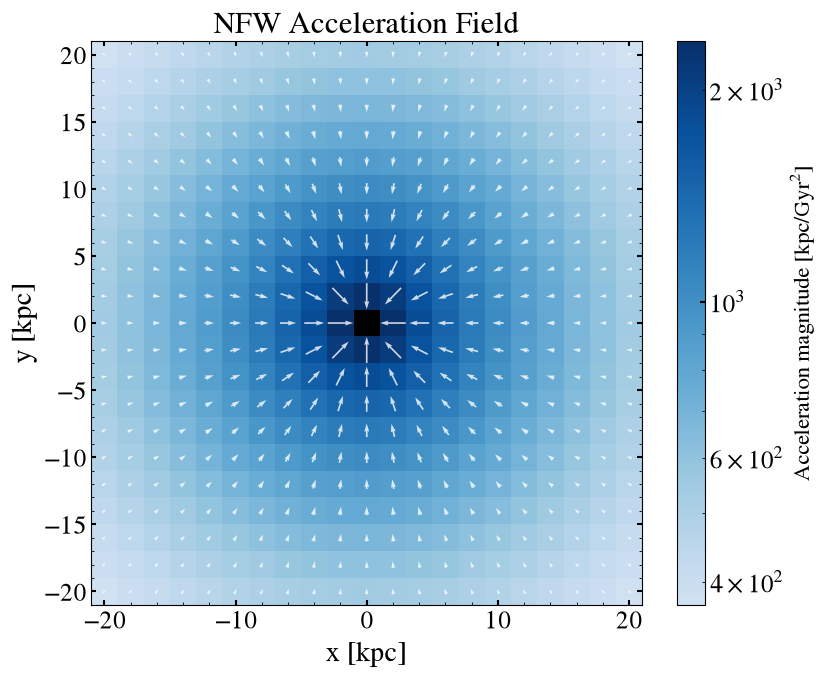

In [2]:
import numpy as np, astropy.units as u
from galpy.potential import PlummerPotential, MovingObjectPotential, NullPotential
from galpy.orbit import Orbit
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
from matplotlib.patches import Circle

from galpy.potential import NFWPotential
from galpy.util.coords import rect_to_cyl, cyl_to_rect_vec

pot = NFWPotential()
pot.turn_physical_on()

x = 0
m = 1e8
b=0.6

import astropy.units as u
#rtide = pot.rtide(R=x*u.kpc, z=0., phi=0., M=m*u.Msun, quantity=True)

pp = PlummerPotential(amp=m*u.Msun, b=b*u.kpc)
# stationary "orbit" sitting at (x,0,0): vxvv = [R, vR, vT, z, vz, phi]
o = Orbit([20*u.kpc, 0*u.km/u.s, 0*u.km/u.s, 0*u.kpc, 0*u.km/u.s, 0*u.rad])
ts = np.linspace(0, 1.0, 200) * u.Gyr
o.integrate(ts, NullPotential())          # zero force + zero v => never drifts

sat_pot_galpy = MovingObjectPotential(o, pot=pp) # Plummer centered at (40,0,0)
sat_pot_galpy.turn_physical_on()

from tambora.dynamics import ExternalGalpyPotential
sat_pot_force_20kpc = ExternalGalpyPotential(pot)
nx, ny = 21, 21
buffer = 20
x_20kpc = np.linspace(- buffer, buffer, nx)
y_20kpc = np.linspace(-buffer, buffer, ny)
X_20kpc, Y_20kpc = np.meshgrid(x_20kpc, y_20kpc)
pos_grid_20kpc = np.column_stack([X_20kpc.ravel(), Y_20kpc.ravel(), np.zeros(X_20kpc.size)])

net_acc_grid_20kpc = sat_pot_force_20kpc.acc(pos_grid_20kpc, t=0.0)
net_U_20kpc = net_acc_grid_20kpc[:, 0].reshape(X_20kpc.shape)
net_V_20kpc = net_acc_grid_20kpc[:, 1].reshape(Y_20kpc.shape)

mag_20kpc = np.hypot(net_U_20kpc, net_V_20kpc)
plt.figure(figsize=(8.5, 7))
cmap = plt.cm.colors.ListedColormap(
        plt.cm.Blues(np.linspace(0.2, 1.0, 256))
    )
cmap.set_bad('k')

from matplotlib.colors import LogNorm
norm = LogNorm(vmin = np.nanmin(mag_20kpc), vmax = np.nanmax(mag_20kpc))
pcm = plt.pcolormesh(
    X_20kpc, Y_20kpc, mag_20kpc,
    shading='auto',
    cmap= cmap,
    norm=norm
    )
plt.colorbar(pcm, label='Acceleration magnitude [kpc/Gyr$^2$]')

plt.quiver(
    X_20kpc, Y_20kpc, net_U_20kpc, net_V_20kpc,
    angles='xy',
    scale_units='xy',
    scale=1200., #2.,
    width=0.003,
    alpha=0.8,
    color='white',
    pivot='mid',
)

plt.xlabel("x [kpc]", fontsize=20)
plt.ylabel("y [kpc]", fontsize=20)
plt.title("NFW Acceleration Field", fontsize=22)
# plt.xlim(20 - 2 * rtide.value, 20 + 2 * rtide.value)
# plt.ylim(-2 * rtide.value, 2 * rtide.value)

plt.tight_layout()
plt.show()


(np.float64(-10.0), np.float64(10.0), np.float64(-10.0), np.float64(10.0))

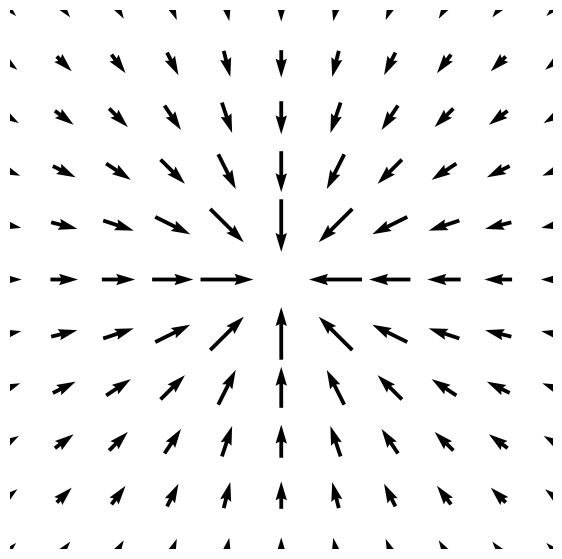

In [3]:

pot = NFWPotential()
pot.turn_physical_on()

x = 0
m = 1e8
b=0.6

pp = PlummerPotential(amp=m*u.Msun, b=b*u.kpc)
# stationary "orbit" sitting at (x,0,0): vxvv = [R, vR, vT, z, vz, phi]
o = Orbit([20*u.kpc, 0*u.km/u.s, 0*u.km/u.s, 0*u.kpc, 0*u.km/u.s, 0*u.rad])
ts = np.linspace(0, 1.0, 200) * u.Gyr
o.integrate(ts, NullPotential())          # zero force + zero v => never drifts

sat_pot_galpy = MovingObjectPotential(o, pot=pp) # Plummer centered at (40,0,0)
sat_pot_galpy.turn_physical_on()

from tambora.dynamics import ExternalGalpyPotential
sat_pot_force_20kpc = ExternalGalpyPotential(pot)
nx, ny = 21, 21
buffer = 20
x_20kpc = np.linspace(- buffer, buffer, nx)
y_20kpc = np.linspace(-buffer, buffer, ny)
X_20kpc, Y_20kpc = np.meshgrid(x_20kpc, y_20kpc)
pos_grid_20kpc = np.column_stack([X_20kpc.ravel(), Y_20kpc.ravel(), np.zeros(X_20kpc.size)])

net_acc_grid_20kpc = sat_pot_force_20kpc.acc(pos_grid_20kpc, t=0.0)
net_U_20kpc = net_acc_grid_20kpc[:, 0].reshape(X_20kpc.shape)
net_V_20kpc = net_acc_grid_20kpc[:, 1].reshape(Y_20kpc.shape)

mag_20kpc = np.hypot(net_U_20kpc, net_V_20kpc)
plt.figure(figsize=(7, 7))
cmap = plt.cm.colors.ListedColormap(
        plt.cm.Blues(np.linspace(0.2, 1.0, 256))
    )
cmap.set_bad('k')
from matplotlib.colors import LogNorm
norm = LogNorm(vmin = np.nanmin(mag_20kpc), vmax = np.nanmax(mag_20kpc))
# pcm = plt.pcolormesh(
#     X_20kpc, Y_20kpc, mag_20kpc,
#     shading='auto',
#     cmap= cmap,
#     norm=norm
#     )
#plt.colorbar(pcm, label='Acceleration magnitude [kpc/Gyr$^2$]')

plt.quiver(
    X_20kpc, Y_20kpc, net_U_20kpc, net_V_20kpc,
    angles='xy',
    scale_units='xy',
    scale=1200., #2.,
    width=0.007,
    alpha=1.0,
    color='k',
    pivot='mid',
)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
#plt.tight_layout()
plt.axis('off')
#plt.savefig('NFW_acc_vector_field.png', dpi=200)


Note that the `turn_physical_on()` method is used on the potential before it is passed to tambora. galpy potentials can be defined in internal units, leaving the true physical scale ambigous (read more about galpy unit conventions in the [galpy documentation](https://docs.galpy.org/en/v1.11.2/getting_started.html#units-in-galpy)). To avoid this ambiguity, be sure to always turn on the physical units of your galpy potential before passing it to tambora to avoid a warning. 

> **Tip:** Update galpy to a version newer than 1.11.2 for a major speedup when using non-spherical potentials.

## Tidal Tensor Approximation ({class}`~tambora.dynamics.forces.external_force.TidalTensorGalpyForce`)

The acceleration from an external conservative force felt at a point, $\vec{r}_c$, can be taylor expanded to first order (from [Dynamics and Astrophysics of Galaxies, $\S$ 19.4.2.2](https://galaxiesbook.org/chapters/IV-03.-Hierarchical-Galaxy-Formation_4-Dynamical-processes.html#mjx-eqn-eq-hierarchgal-ttensor)):

$$
\begin{equation}
-{\partial \Phi \over \partial x_i} \approx -{\partial \Phi \over \partial x_i}\Bigg|_{\vec{x} = \vec{r}_c} - \sum_j{\Phi_{ij}\,(x_j - r_{c, j})}\,,\; \mathrm{where}\quad
\Phi_{ij}(t) = {\partial^2 \Phi(\vec{x},t) \over \partial x_i\partial x_j}\Bigg|_{\vec{x}=\vec{r}_c}
\end{equation}
$$

This is known as the [distant tide approximation](https://galaxiesbook.org/chapters/IV-03.-Hierarchical-Galaxy-Formation_4-Dynamical-processes.html#when-considering-the-effect-of-tides-on), often used to understand the effects of tidal forces on a satellite. The first term of the expansion drives the bulk motion of the satellite relative to the host. However, the second term is of particular interest because it provides the torques that largely dictate *how* the satellite disrupts. The {class}`~tambora.dynamics.forces.external_force.TidalTensorGalpyForce` gives the acceleration from only this second term of the expansion for a given galpy potential.


When instantiating {class}`~tambora.dynamics.forces.external_force.TidalTensorGalpyForce`, you can also choose to either:
    
(a) fix the location where the tidal tensor, $\Phi_{ij}$, is evaluated with the `center` argument.

In [4]:
from tambora.dynamics import TidalTensorGalpyForce
from galpy.potential import NFWPotential

hostpot = NFWPotential()
hostpot.turn_physical_on()

tide_approx = TidalTensorGalpyForce(hostpot, center=[20, 0, 0])

or, (b, **default**) reevaluate $\Phi_{ij}$ at the median position of particles passed during each acceleration or potential evaluation by setting `center=None`.

In [5]:
tide_approx = TidalTensorGalpyForce(hostpot, center=None)

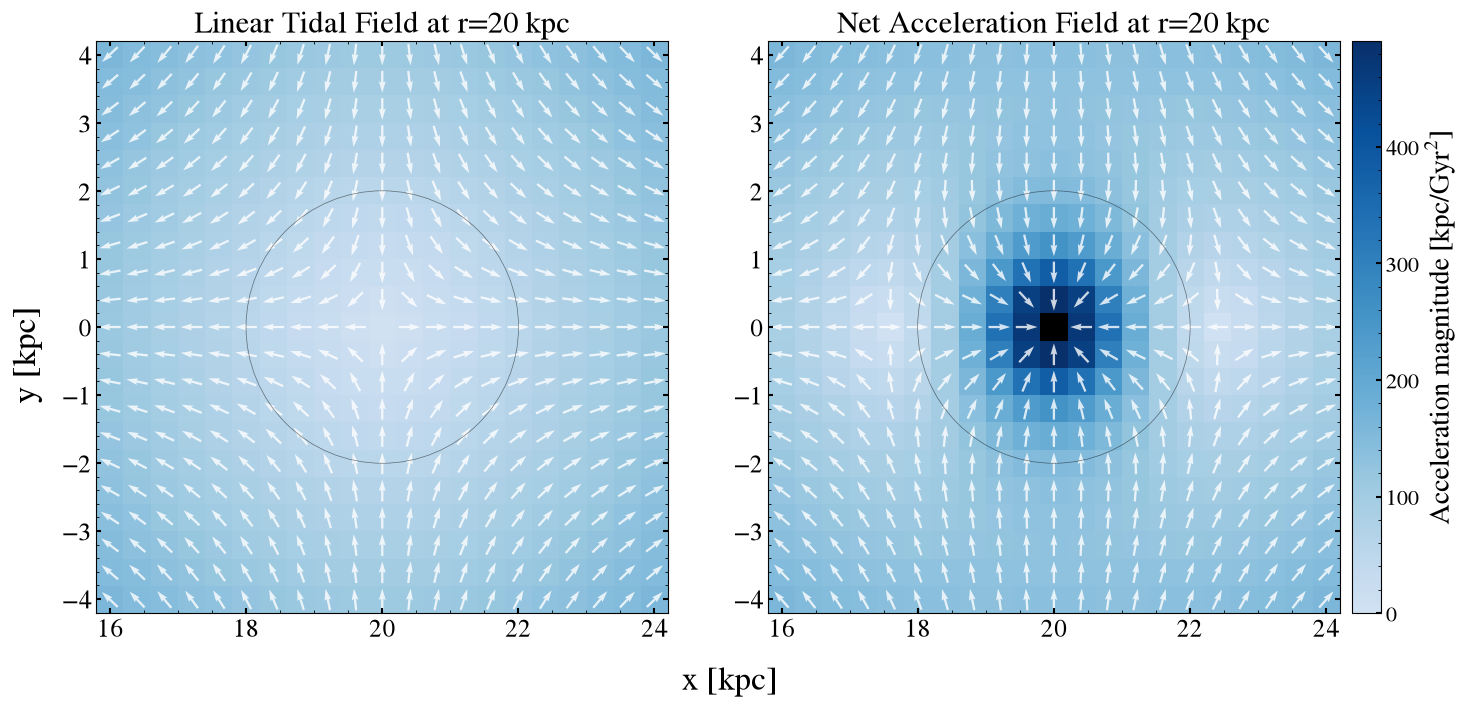

In [6]:
import numpy as np, astropy.units as u
from galpy.potential import PlummerPotential, MovingObjectPotential, NullPotential
from galpy.orbit import Orbit
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 16
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
from matplotlib.patches import Circle

from galpy.potential import NFWPotential
from galpy.util.coords import rect_to_cyl, cyl_to_rect_vec
from tambora.dynamics import TidalTensorGalpyForce

pot = NFWPotential()
pot.turn_physical_on()

x = 20
m = 1e8
b=0.6

import astropy.units as u
rtide = pot.rtide(R=x*u.kpc, z=0., phi=0., M=m*u.Msun, quantity=True)

pp = PlummerPotential(amp=m*u.Msun, b=b*u.kpc)
# stationary "orbit" sitting at (x,0,0): vxvv = [R, vR, vT, z, vz, phi]
o = Orbit([20*u.kpc, 0*u.km/u.s, 0*u.km/u.s, 0*u.kpc, 0*u.km/u.s, 0*u.rad])
ts = np.linspace(0, 1.0, 200) * u.Gyr
o.integrate(ts, NullPotential())          # zero force + zero v => never drifts

sat_pot_galpy = MovingObjectPotential(o, pot=pp) # Plummer centered at (20,0,0)
sat_pot_galpy.turn_physical_on()

from tambora.dynamics import ExternalGalpyPotential
ex_nfw_field_20kpc = TidalTensorGalpyForce(pot, [20, 0, 0])
sat_pot_force_20kpc = ExternalGalpyPotential(sat_pot_galpy)
nx, ny = 21, 21
buffer = 2 * rtide.value 
x_20kpc = np.linspace(20 - buffer, 20 + buffer, nx)
y_20kpc = np.linspace(-buffer, buffer, ny)
X_20kpc, Y_20kpc = np.meshgrid(x_20kpc, y_20kpc)
pos_grid_20kpc = np.column_stack([X_20kpc.ravel(), Y_20kpc.ravel(), np.zeros(X_20kpc.size)])


net_acc_grid_20kpc = sat_pot_force_20kpc.acc(pos_grid_20kpc, t=0.0) + ex_nfw_field_20kpc.acc(pos_grid_20kpc, t=0.0)
net_U_20kpc = net_acc_grid_20kpc[:, 0].reshape(X_20kpc.shape)
net_V_20kpc = net_acc_grid_20kpc[:, 1].reshape(Y_20kpc.shape)

lineartide_grid = ex_nfw_field_20kpc.acc(pos_grid_20kpc, t=0.0)
tide_U_20kpc = lineartide_grid[:, 0].reshape(X_20kpc.shape)
tide_V_20kpc = lineartide_grid[:, 1].reshape(Y_20kpc.shape)

mag_20kpc = np.hypot(net_U_20kpc, net_V_20kpc)
tide_mag_20kpc = np.hypot(tide_U_20kpc, tide_V_20kpc)

# shared color limits across both panels (ignore the satellite-center singularity)
_finite = lambda a: a[np.isfinite(a)]
_both = np.concatenate([_finite(mag_20kpc).ravel(), _finite(tide_mag_20kpc).ravel()])
vmin, vmax = _both.min(), _both.max()

# fixed arrow length (~0.8 of a grid cell) so every arrow is the same size
arrow_len = 0.8 * (x_20kpc[1] - x_20kpc[0])

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
cmap = plt.cm.colors.ListedColormap(
        plt.cm.Blues(np.linspace(0.2, 1.0, 256))
    )
cmap.set_bad('k')

# Linear tidal field on the left, net on the right. Shared color normalization;
# arrows show direction only (all the same length).
panels = [
    (ax[0], tide_U_20kpc, tide_V_20kpc, tide_mag_20kpc, "Linear Tidal Field at r=20 kpc"),
    (ax[1], net_U_20kpc, net_V_20kpc, mag_20kpc, "Net Acceleration Field at r=20 kpc"),
]
caxes = []
for axi, U, V, mag, title in panels:
    pcm = axi.pcolormesh(X_20kpc, Y_20kpc, mag, shading='auto', cmap=cmap,
                         vmin=vmin, vmax=vmax)
    with np.errstate(invalid='ignore', divide='ignore'):
        U_hat, V_hat = U / mag, V / mag
    axi.quiver(
        X_20kpc, Y_20kpc, U_hat, V_hat,
        angles='xy',
        scale_units='xy',
        scale=1.0 / arrow_len,
        width=0.004,
        alpha=0.8,
        color='white',
        pivot='mid',
    )
    axi.add_patch(Circle((20, 0), float(rtide.value),
                         edgecolor='black', facecolor='none', linewidth=0.5, alpha=0.5))
    axi.set_aspect('equal')
    axi.set_title(title, fontsize=22)
    # append a colorbar slot to each panel so both stay the same size; the
    # appended axes matches the (square) panel height exactly.
    divider = make_axes_locatable(axi)
    caxes.append(divider.append_axes("right", size="5%", pad=0.12))

caxes[0].axis('off')  # hide the left slot; only draw the shared colorbar on the right
cb = fig.colorbar(pcm, cax=caxes[1])
cb.set_label('Acceleration magnitude [kpc/Gyr$^2$]', fontsize=20)
cb.ax.tick_params(labelsize=16)

fig.supxlabel("x [kpc]", fontsize=24)
fig.supylabel("y [kpc]", fontsize=24)

plt.tight_layout()
plt.show()


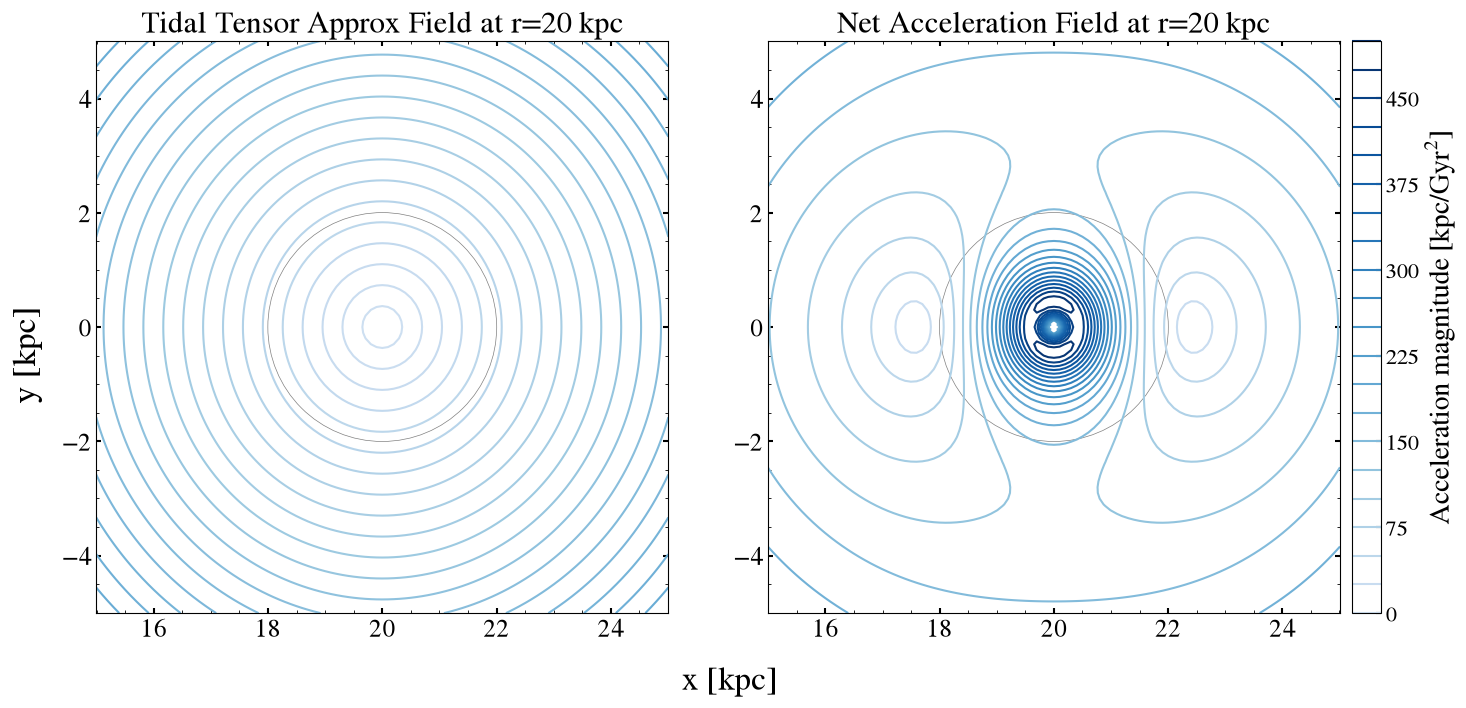

In [9]:
import numpy as np, astropy.units as u
from galpy.potential import PlummerPotential, MovingObjectPotential, NullPotential
from galpy.orbit import Orbit
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 16
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
from matplotlib.patches import Circle

from galpy.potential import NFWPotential
from galpy.util.coords import rect_to_cyl, cyl_to_rect_vec
from tambora.dynamics import TidalTensorGalpyForce

pot = NFWPotential()
pot.turn_physical_on()

x = 20
m = 1e8
b=0.6

import astropy.units as u
rtide = pot.rtide(R=x*u.kpc, z=0., phi=0., M=m*u.Msun, quantity=True)

pp = PlummerPotential(amp=m*u.Msun, b=b*u.kpc)
# stationary "orbit" sitting at (x,0,0): vxvv = [R, vR, vT, z, vz, phi]
o = Orbit([20*u.kpc, 0*u.km/u.s, 0*u.km/u.s, 0*u.kpc, 0*u.km/u.s, 0*u.rad])
ts = np.linspace(0, 1.0, 200) * u.Gyr
o.integrate(ts, NullPotential())          # zero force + zero v => never drifts

sat_pot_galpy = MovingObjectPotential(o, pot=pp) # Plummer centered at (20,0,0)
sat_pot_galpy.turn_physical_on()

from tambora.dynamics import ExternalGalpyPotential
ex_nfw_field_20kpc = TidalTensorGalpyForce(pot, [20, 0, 0])
sat_pot_force_20kpc = ExternalGalpyPotential(sat_pot_galpy)
nx, ny = 101, 101
buffer = 2.5 * rtide.value 
x_20kpc = np.linspace(20 - buffer, 20 + buffer, nx)
y_20kpc = np.linspace(-buffer, buffer, ny)
X_20kpc, Y_20kpc = np.meshgrid(x_20kpc, y_20kpc)
pos_grid_20kpc = np.column_stack([X_20kpc.ravel(), Y_20kpc.ravel(), np.zeros(X_20kpc.size)])


net_acc_grid_20kpc = sat_pot_force_20kpc.acc(pos_grid_20kpc, t=0.0) + ex_nfw_field_20kpc.acc(pos_grid_20kpc, t=0.0)
net_U_20kpc = net_acc_grid_20kpc[:, 0].reshape(X_20kpc.shape)
net_V_20kpc = net_acc_grid_20kpc[:, 1].reshape(Y_20kpc.shape)

lineartide_grid = ex_nfw_field_20kpc.acc(pos_grid_20kpc, t=0.0)
tide_U_20kpc = lineartide_grid[:, 0].reshape(X_20kpc.shape)
tide_V_20kpc = lineartide_grid[:, 1].reshape(Y_20kpc.shape)

mag_20kpc = np.hypot(net_U_20kpc, net_V_20kpc)
tide_mag_20kpc = np.hypot(tide_U_20kpc, tide_V_20kpc)

# shared color limits across both panels (ignore the satellite-center singularity)
_finite = lambda a: a[np.isfinite(a)]
_both = np.concatenate([_finite(mag_20kpc).ravel(), _finite(tide_mag_20kpc).ravel()])
vmin, vmax = _both.min(), _both.max()

# fixed arrow length (~0.8 of a grid cell) so every arrow is the same size
arrow_len = 0.8 * (x_20kpc[1] - x_20kpc[0])

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
cmap = plt.cm.colors.ListedColormap(
        plt.cm.Blues(np.linspace(0.2, 1.0, 256))
    )
cmap.set_bad('k')

# Linear tidal field on the left, net on the right. Shared color normalization;
# arrows show direction only (all the same length).
panels = [
    (ax[0], tide_U_20kpc, tide_V_20kpc, tide_mag_20kpc, "Tidal Tensor Approx Field at r=20 kpc"),
    (ax[1], net_U_20kpc, net_V_20kpc, mag_20kpc, "Net Acceleration Field at r=20 kpc"),
]
caxes = []
for axi, U, V, mag, title in panels:
    pcm = axi.contour(X_20kpc, Y_20kpc, mag, cmap=cmap,
                         vmin=vmin, vmax=vmax, levels=20)
    with np.errstate(invalid='ignore', divide='ignore'):
        U_hat, V_hat = U / mag, V / mag
    # axi.quiver(
    #     X_20kpc, Y_20kpc, U_hat, V_hat,
    #     angles='xy',
    #     scale_units='xy',
    #     scale=1.0 / arrow_len,
    #     width=0.004,
    #     alpha=0.8,
    #     color='white',
    #     pivot='mid',
    # )
    axi.add_patch(Circle((20, 0), float(rtide.value),
                         edgecolor='black', facecolor='none', linewidth=0.5, alpha=0.5))
    axi.set_aspect('equal')
    axi.set_title(title, fontsize=22)
    # append a colorbar slot to each panel so both stay the same size; the
    # appended axes matches the (square) panel height exactly.
    divider = make_axes_locatable(axi)
    caxes.append(divider.append_axes("right", size="5%", pad=0.12))

caxes[0].axis('off')  # hide the left slot; only draw the shared colorbar on the right
cb = fig.colorbar(pcm, cax=caxes[1])
cb.set_label('Acceleration magnitude [kpc/Gyr$^2$]', fontsize=20)
cb.ax.tick_params(labelsize=16)

fig.supxlabel("x [kpc]", fontsize=24)
fig.supylabel("y [kpc]", fontsize=24)

plt.tight_layout()
plt.show()

## Supported galpy potentials


The following galpy potentials, wrappers, and any combination of them are supported by tambora:

**Spherical**

- [Burkert potential (`BurkertPotential`)](https://docs.galpy.org/en/latest/reference/potentialburkert.html) 
- [Spherical Cored Dehnen potential (`DehnenCoreSphericalPotential`)](https://docs.galpy.org/en/latest/reference/potentialcoredehnen.html)
- [Spherical Dehnen potential (`DehnenSphericalPotential`)](https://docs.galpy.org/en/latest/reference/potentialdehnen.html)
- [Einasto potential (`EinastoPotential`)](https://docs.galpy.org/en/latest/reference/potentialeinasto.html)
- [Hernquist potential (`HernquistPotential`)](https://docs.galpy.org/en/latest/reference/potentialhernquist.html)
- [Homogeneous sphere potential (`HomogeneousSpherePotential`)](https://docs.galpy.org/en/latest/reference/potentialhomogsphere.html)
- [Interpolated spherical potential (`interpSphericalPotential`)](https://docs.galpy.org/en/latest/reference/potentialinterpsphere.html)
- [Isochrone potential (`IsochronePotential`)](https://docs.galpy.org/en/latest/reference/potentialisochrone.html)
- [Jaffe potential (`JaffePotential`)](https://docs.galpy.org/en/latest/reference/potentialjaffe.html)
- [Kepler potential (`KeplerPotential`)](https://docs.galpy.org/en/latest/reference/potentialkepler.html)
- [King potential (`KingPotential`)](https://docs.galpy.org/en/latest/reference/potentialking.html)
- [NFW potential (`NFWPotential`)](https://docs.galpy.org/en/latest/reference/potentialnfw.html)
- [Plummer potential (`PlummerPotential`)](https://docs.galpy.org/en/latest/reference/potentialplummer.html)
- [Power-law density spherical potential (`PowerSphericalPotential`)](https://docs.galpy.org/en/latest/reference/potentialpowerspher.html)
- [Power-law density spherical potential with an exponential cut-off (`PowerSphericalPotentialwCutoff`)](https://docs.galpy.org/en/latest/reference/potentialpowerspherwcut.html)
- [Pseudo-isothermal potential (`PseudoIsothermalPotential`)](https://docs.galpy.org/en/latest/reference/potentialpseudoiso.html)
- [Spherical Shell potential (`SphericalShellPotential`)](https://docs.galpy.org/en/latest/reference/potentialsphericalshell.html)
- [Double power-law density spherical potential (`TwoPowerSphericalPotential`)](https://docs.galpy.org/en/latest/reference/potentialdoublepowerspher.html)

**Axisymmetric**

- [Double exponential disk potential (`DoubleExponentialDiskPotential`)](https://docs.galpy.org/en/latest/reference/potentialdoubleexp.html)
- [Flattened power-law potential (`FlattenedPowerPotential`)](https://docs.galpy.org/en/latest/reference/potentialflattenedpower.html)
- [Interpolated axisymmetric potential (`interpRZPotential`)](https://docs.galpy.org/en/latest/reference/potentialinterprz.html)
- [Kuzmin disk potential (`KuzminDiskPotential`)](https://docs.galpy.org/en/latest/reference/potentialkuzmindisk.html)
- [Kuzmin-Kutuzov Staeckel potential (`KuzminKutuzovStaeckelPotential`)](https://docs.galpy.org/en/latest/reference/potentialkuzminkutuzov.html)
- [Logarithmic halo potential (`LogarithmicHaloPotential`)](https://docs.galpy.org/en/latest/reference/potentialloghalo.html)
- [Miyamoto-Nagai potential (`MiyamotoNagaiPotential`)](https://docs.galpy.org/en/latest/reference/potentialmiyamoto.html)
- [Three Miyamoto-Nagai disk approximation to an exponential disk (`MN3ExponentialDiskPotential`)](https://docs.galpy.org/en/latest/reference/potential3mn.html)
- [Razor-thin exponential disk potential (`RazorThinExponentialDiskPotential`)](https://docs.galpy.org/en/latest/reference/potentialrazorexp.html)
- [Ring potential (`RingPotential`)](https://docs.galpy.org/en/latest/reference/potentialring.html)

**Ellipsoidal triaxial**

- [Perfect Ellipsoid potential (`PerfectEllipsoidPotential`)](https://docs.galpy.org/en/latest/reference/potentialperfectellipsoid.html)
- [Triaxial Gaussian potential (`TriaxialGaussianPotential`)](https://docs.galpy.org/en/latest/reference/potentialtriaxialgaussian.html)
- [Triaxial Hernquist potential (`TriaxialHernquistPotential`)](https://docs.galpy.org/en/latest/reference/potentialtriaxialhernquist.html)
- [Triaxial Jaffe potential (`TriaxialJaffePotential`)](https://docs.galpy.org/en/latest/reference/potentialtriaxialjaffe.html)
- [Triaxial NFW potential (`TriaxialNFWPotential`)](https://docs.galpy.org/en/latest/reference/potentialtriaxialnfw.html)
- [Double power-law density triaxial potential (`TwoPowerTriaxialPotential`)](https://docs.galpy.org/en/latest/reference/potentialdoublepowertriaxial.html)

**Spiral, bar, and miscellaneous**

- [Dehnen bar potential (`DehnenBarPotential`)](https://docs.galpy.org/en/latest/reference/potentialdehnenbar.html)
- [Ferrers potential (`FerrersPotential`)](https://docs.galpy.org/en/latest/reference/potentialferrers.html)
- [Softened-needle bar potential (`SoftenedNeedleBarPotential`)](https://docs.galpy.org/en/latest/reference/potentialsoftenedneedle.html)
- [Spiral arms potential (`SpiralArmsPotential`)](https://docs.galpy.org/en/latest/reference/potentialspiralarms.html)
- [Constant (null) potential (`NullPotential`)](https://docs.galpy.org/en/latest/reference/potentialnull.html)
- `MWPotential2014` (composite: NFW + Miyamoto-Nagai + power-law bulge)


**Potential Wrappers**

- [Adiabatic contraction wrapper 🚧 (`AdiabaticContractionWrapperPotential`)](https://docs.galpy.org/en/latest/reference/potentialadiabaticcontractwrapper.html)
- [Any time-dependent amplitude wrapper 🚧 (`TimeDependentAmplitudeWrapperPotential`)](https://docs.galpy.org/en/latest/reference/potentialtimedependentamplitude.html)
- [Corotating rotation wrapper (`CorotatingRotationWrapperPotential`)](https://docs.galpy.org/en/latest/reference/potentialcorotwrapper.html)
- [Cylindrically-separable wrapper 🚧 (`CylindricallySymmetricWrapperPotential`)](https://docs.galpy.org/en/latest/reference/potentialcylindricallyseparablewrapper.html)
- [Dehnen-like smoothing wrapper (`DehnenSmoothWrapperPotential`)](https://docs.galpy.org/en/latest/reference/potentialdehnensmoothwrapper.html)
- [Gaussian-modulated amplitude wrapper (`GaussianAmplitudeWrapperPotential`)](https://docs.galpy.org/en/latest/reference/potentialgaussampwrapper.html)
- [Kuzmin-like wrapper (`KuzminLikeWrapperPotential`)](https://docs.galpy.org/en/latest/reference/potentialkuzminlikewrapper.html)
- [Oblate Staeckel wrapper 🚧 (`OblatePerfectEllipsoidWrapperPotential`)](https://docs.galpy.org/en/latest/reference/potentialoblatestaeckelwrapper.html)
- [Solid-body rotation wrapper (`SolidBodyRotationWrapperPotential`)](https://docs.galpy.org/en/latest/reference/potentialsolidbodyrotationwrapper.html)
- [Rotate-and-tilt wrapper (`RotateAndTiltWrapperPotential`)](https://docs.galpy.org/en/latest/reference/potentialrotateandtiltwrapper.html)

## agama 🚧

🚧 *Still working on it...* 🚧

## API
### Classes

```{eval-rst}
.. autoclass:: tambora.dynamics.forces.external_force.ExternalGalpyPotential

.. autoclass:: tambora.dynamics.forces.external_force.TidalTensorGalpyForce

.. autoclass:: tambora.dynamics.forces.NullExternalForce
```

### Methods
```{eval-rst}
.. automethod:: tambora.simulation.Sim.add_external_pot

.. automethod:: tambora.dynamics.forces.external_force.ExternalGalpyPotential.acc

.. automethod:: tambora.dynamics.forces.external_force.ExternalGalpyPotential.potential

.. automethod:: tambora.dynamics.forces.external_force.ExternalGalpyPotential.acc_and_potential

```

**NOTE**: Need to make sure that forces aren't duplicated, and raise a warning if they are.